In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

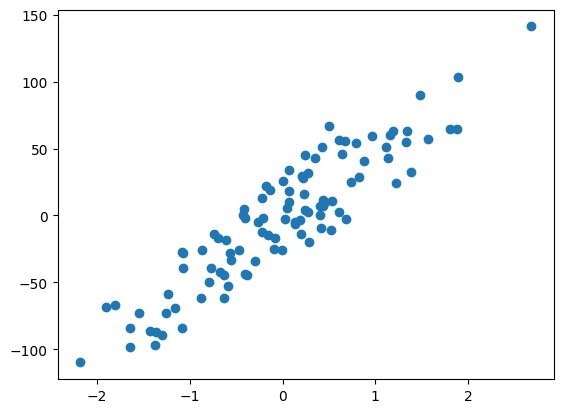

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
lr = LinearRegression()

In [7]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[46.99296511]
-1.5010766375094462


In [8]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8183798574665643

In [9]:
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=10))

np.float64(0.8153054548687859)

In [85]:
class GDRegressor:

    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
    def fit(self,X,y):
        # calculate the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y-self.m*X.ravel()-self.b)
            loss_slope_m = -2 * np.sum((y-self.m*X.ravel()-self.b)*X.ravel())
            
            self.b = self.b-(self.lr * loss_slope_b)
            self.m = self.m-(self.lr * loss_slope_m)
            
        print(self.m,self.b)
    def predict(self,X):
        return self.m * X + self.b
            

In [86]:
gd= GDRegressor(0.001,50)

In [87]:
gd.fit(X,y)

67.54122277460043 -0.5949628341004101


In [88]:
gd.predict(X)

array([[ -86.70859505],
       [ -71.49808651],
       [  64.23113868],
       [ -19.66964269],
       [ -78.05334835],
       [ 109.49420427],
       [  76.66128819],
       [ -95.70857096],
       [  29.96246158],
       [  -7.17095872],
       [-135.11212884],
       [ -62.2736195 ],
       [ -73.83631658],
       [ -78.82445616],
       [  60.47929047],
       [ -67.61571854],
       [  79.06513926],
       [  17.08386837],
       [ -42.02435755],
       [ -15.6362377 ],
       [-158.52221101],
       [ -42.64553314],
       [  -4.45748036],
       [  15.00873874],
       [ -21.18700894],
       [  33.022982  ],
       [  47.45650072],
       [   6.15455908],
       [   6.08446842],
       [ -56.54090315],
       [  37.59656237],
       [  -5.2999534 ],
       [ -33.65829086],
       [  57.37314706],
       [  34.89467821],
       [ -29.11016217],
       [ -22.16464444],
       [ -29.89992333],
       [ -54.87855474],
       [  59.15558369],
       [-104.12400529],
       [  -6.534

In [90]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8824842665595417